## Import libraries

In [1]:
import numpy as np
import pandas as pd
import darts
import optuna
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date, timedelta
from darts import TimeSeries
from darts.dataprocessing.transformers import MissingValuesFiller, Scaler
from darts.models import XGBModel
from darts.metrics import rmse
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

## Load the data

In [2]:
df = pd.read_csv('US_TGA_deposits.csv')
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d')
series = darts.TimeSeries.from_dataframe(df, 'DATE', 'FLOW', fill_missing_dates=False, freq='D')


## Explore the data

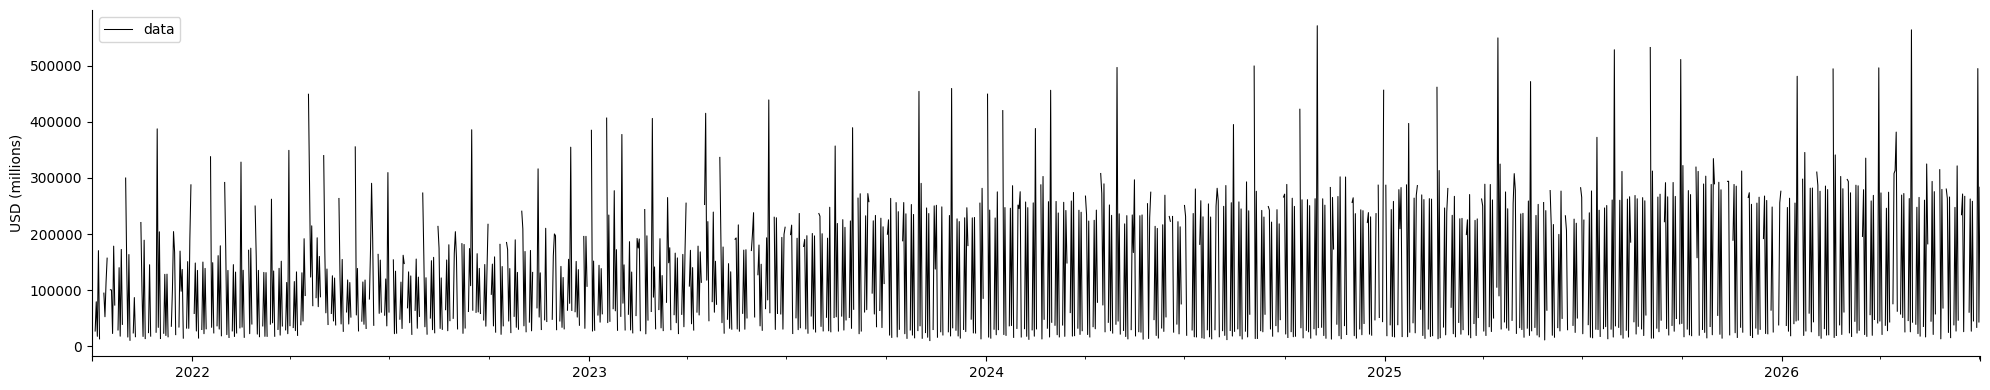

In [3]:
plt.figure(figsize=(20,4))
series.plot(color='k', linewidth=.75, label='data')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.ylabel('USD (millions)', fontweight='normal')
plt.xlabel(None)
plt.legend()
plt.tight_layout()
plt.show()


## Rescale the data for the algorithm

In [4]:
# load Darts scaler 
scaler = Scaler(global_fit=True)
series_nonans = MissingValuesFiller().transform(series)
series_scaled = scaler.fit_transform(series_nonans)


## Split data

In [5]:
date_cut = '2026-01-01'
date_val = '2025-01-01'

target_date = pd.Timestamp(date_cut)
split_index = series.time_index.get_loc(target_date)
split_point = series_scaled.time_index[split_index]
train, test = series_scaled.split_before(split_point)

target_date = pd.Timestamp(date_val)
split_index_val = series.time_index.get_loc(target_date)
split_point_val = series_scaled.time_index[split_index_val]
train_val, test_val = train.split_before(split_point_val)


## Plot split data

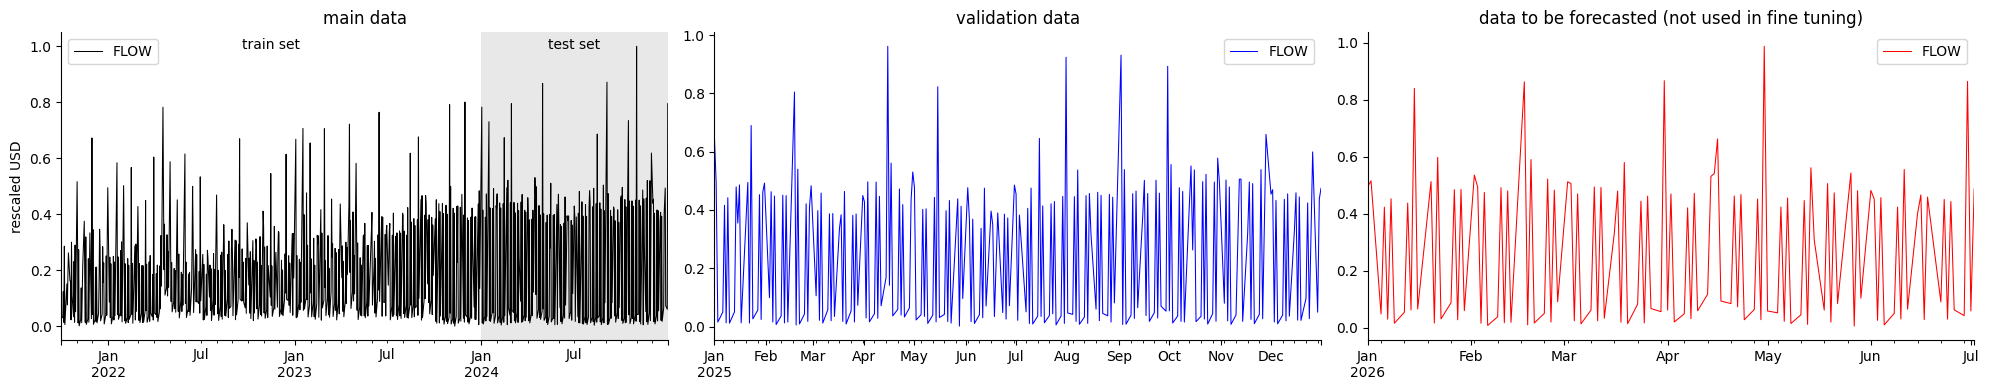

In [6]:
plt.figure(figsize=(20,4))

plt.subplot(131)
ax = train_val.plot(color='k', linewidth=.75)
start = datetime(2024, 1, 1)
xmin, xmax = ax.get_xlim()
start_num = mdates.date2num(start)
ax.axvspan(start, xmax, facecolor='lightgray', alpha=0.5, zorder=-1)
start_norm = (start_num - xmin) / (xmax - xmin)
clear_center_x  = 0.5 * start_norm
shaded_center_x = 0.5 * (start_norm + 1.0)
ax.text(clear_center_x, 0.98, "train set", ha="center", va="top", transform=ax.transAxes)
ax.text(shaded_center_x, 0.98, "test set", ha="center", va="top", transform=ax.transAxes)
plt.title('main data')
plt.ylabel('rescaled USD')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel(None)

plt.subplot(132)
test_val.plot(color='b', linewidth=.75)
plt.title('validation data')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel(None)

plt.subplot(133)
test.plot(color='r', linewidth=.75)
plt.title('data to be forecasted (not used in fine tuning)')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel(None)

plt.tight_layout()
plt.show()


## Fine tuning

In [7]:
SEED = 0
limits = {"lags_lb": 1, "lags_ub": 360, "max_depth_lb": 3, "max_depth_ub": 9, "n_estimators_lb": 10, "n_estimators_ub": 100, "learning_rate_lb": 0.001, "learning_rate_ub": 0.5, "min_child_weight_lb": 1.0, "min_child_weight_ub": 10.0, "subsample_lb": 0.5, "subsample_ub": 1.0, "colsample_bytree_lb": 0.5, "colsample_bytree_ub": 1.0, "gamma_lb": 0.0, "gamma_ub": 5.0, "n_trials": 25}

sampler = optuna.samplers.TPESampler(
    seed=SEED,
    multivariate=True,
    group=True,
    n_startup_trials=50,
)

def objective(trial):
    lags = trial.suggest_int("lags", limits["lags_lb"], limits["lags_ub"])
    max_depth = trial.suggest_int("max_depth", limits["max_depth_lb"], limits["max_depth_ub"])
    n_estimators = trial.suggest_int("n_estimators", limits["n_estimators_lb"], limits["n_estimators_ub"])
    learning_rate = trial.suggest_float(
        "learning_rate",
        limits["learning_rate_lb"],
        limits["learning_rate_ub"],
        log=True,
    )

    min_child_weight = trial.suggest_float(
        "min_child_weight",
        limits["min_child_weight_lb"],
        limits["min_child_weight_ub"],
    )
    subsample = trial.suggest_float(
        "subsample",
        limits["subsample_lb"],
        limits["subsample_ub"],
    )
    colsample_bytree = trial.suggest_float(
        "colsample_bytree",
        limits["colsample_bytree_lb"],
        limits["colsample_bytree_ub"],
    )
    gamma = trial.suggest_float(
        "gamma",
        limits["gamma_lb"],
        limits["gamma_ub"],
    )

    model = XGBModel(
        random_state=SEED,
        lags=lags,
        max_depth=max_depth,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        output_chunk_length=1,
        likelihood='quantile',
        quantiles=[0.05, 0.5, 0.95],
        model_kwargs={
            "min_child_weight": min_child_weight,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "gamma": gamma,
        },
    )

    model.fit(
        train_val,
        val_series=test_val,
        verbose=False,
    )

    pred = model.predict(n=len(test_val))

    error = rmse(
        scaler.inverse_transform(test_val),
        scaler.inverse_transform(pred),
    )

    return error


optuna.logging.set_verbosity(optuna.logging.WARNING) # do not print progress (comment to see progress messages)

# run the hyperparameter search algorithm
study = optuna.create_study(direction="minimize", sampler=sampler) # create the object that will explore the hyperparameters
study.optimize(objective, n_trials=limits['n_trials']) # run fine tuning
optimal_pars = study.best_params # save best hyperparameters dictionary

print('Fine tuning is done.')


Fine tuning is done.


## Train and forecast 2026

In [8]:
date_cut = '2026-01-01'
target_date = pd.Timestamp(date_cut)
split_index = series.time_index.get_loc(target_date)
split_point = series_scaled.time_index[split_index]
train, test = series_scaled.split_before(split_point)

model = XGBModel(
    random_state=SEED,
    lags=optimal_pars['lags'],
    #lags_future_covariates=[0],
    max_depth=optimal_pars['max_depth'],
    n_estimators=optimal_pars['n_estimators'],
    learning_rate=optimal_pars['learning_rate'],
    likelihood='quantile',
    quantiles=[0.05, 0.5, 0.95],
    model_kwargs={
        "min_child_weight": optimal_pars['min_child_weight'],
        "subsample": optimal_pars['subsample'],
        "colsample_bytree": optimal_pars['colsample_bytree'],
        "gamma": optimal_pars['gamma'],
    },
)


model.fit(train)#, future_covariates=cov_full)
forecast = model.predict(n=len(test))#, future_covariates=cov_full)
df_forecast = scaler.inverse_transform(forecast).to_dataframe()


print('Model has been trained. Forecast is ready!')


Model has been trained. Forecast is ready!


## Plot forecast of 2026

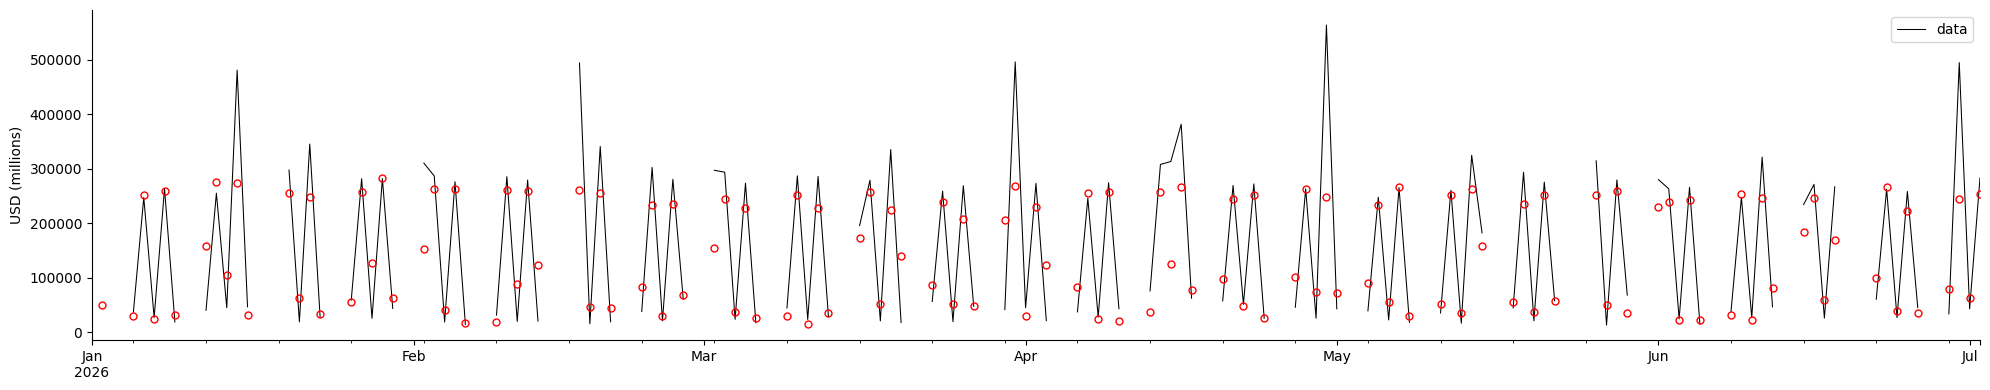

In [9]:
# prepare data for plot
year_df = series.to_dataframe()
year_df = year_df[year_df.index.year == 2026] # isolate 2025
year_ts = TimeSeries.from_dataframe(year_df)
obs = ~np.isnan(year_ts.values()).flatten() # plot only days with observations
xx = df_forecast.index[obs]
yy = df_forecast.FLOW.values[obs]

# plot a chart
plt.figure(figsize=(20,4))
year_ts.plot(color='k', linewidth=.75, label='data')
plt.plot(xx, yy, 'or', markersize=5, mfc='none', label='forecast')
plt.ylabel('USD (millions)', fontweight='normal')
plt.xlabel(None)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Construct future covariates

In [10]:
threshold = 250000
tau = scaler.transform(TimeSeries.from_values([threshold])).values()[0][0]

date_index = series_scaled.time_index
values = series_scaled.univariate_values()

df_vf = pd.DataFrame({
    'DATE': pd.to_datetime(date_index).normalize(),
    'FLOW': values
})

df_vf['FUTURE_VALUE'] = 0.0
df_vf.loc[df_vf.FLOW>tau, 'FUTURE_VALUE'] = df_vf[df_vf.FLOW>tau].FLOW.values * (1 + .2 * np.random.choice([-1,1], size=sum(df_vf.FLOW>tau)) * np.random.rand(sum(df_vf.FLOW>tau)))
df_vf['NOFLOW'] = ((df_vf['DATE'].dt.dayofweek >= 5) & (df_vf.FLOW.isnull())).astype(int)
cov_full = darts.TimeSeries.from_dataframe(df_vf, 'DATE', ['FUTURE_VALUE', 'NOFLOW'], fill_missing_dates=False, freq='D')
cov_train, cov_test = cov_full.split_before(split_point_val)


## Plot outliers versus future covariates

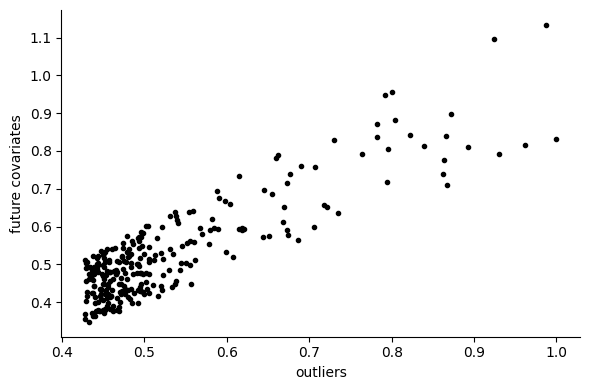

In [11]:
plt.figure(figsize=(6,4))
plt.plot(df_vf.FLOW.values[df_vf.FLOW.values>tau], df_vf.FUTURE_VALUE.values[df_vf.FLOW.values>tau], '.k')
plt.xlabel('outliers')
plt.ylabel('future covariates')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Fine tuning with future covariates

In [12]:
SEED = 0
limits = {"lags_lb": 1, "lags_ub": 360, "max_depth_lb": 3, "max_depth_ub": 9, "n_estimators_lb": 10, "n_estimators_ub": 100, "learning_rate_lb": 0.001, "learning_rate_ub": 0.5, "min_child_weight_lb": 1.0, "min_child_weight_ub": 10.0, "subsample_lb": 0.5, "subsample_ub": 1.0, "colsample_bytree_lb": 0.5, "colsample_bytree_ub": 1.0, "gamma_lb": 0.0, "gamma_ub": 5.0, "n_trials": 25}

sampler = optuna.samplers.TPESampler(
    seed=SEED,
    multivariate=True,
    group=True,
    n_startup_trials=50,
)

def objective(trial):
    lags = trial.suggest_int("lags", limits["lags_lb"], limits["lags_ub"])
    max_depth = trial.suggest_int("max_depth", limits["max_depth_lb"], limits["max_depth_ub"])
    n_estimators = trial.suggest_int("n_estimators", limits["n_estimators_lb"], limits["n_estimators_ub"])
    learning_rate = trial.suggest_float(
        "learning_rate",
        limits["learning_rate_lb"],
        limits["learning_rate_ub"],
        log=True,
    )

    min_child_weight = trial.suggest_float(
        "min_child_weight",
        limits["min_child_weight_lb"],
        limits["min_child_weight_ub"],
    )
    subsample = trial.suggest_float(
        "subsample",
        limits["subsample_lb"],
        limits["subsample_ub"],
    )
    colsample_bytree = trial.suggest_float(
        "colsample_bytree",
        limits["colsample_bytree_lb"],
        limits["colsample_bytree_ub"],
    )
    gamma = trial.suggest_float(
        "gamma",
        limits["gamma_lb"],
        limits["gamma_ub"],
    )

    model = XGBModel(
        random_state=SEED,
        lags=lags,
        lags_future_covariates=[0],
        max_depth=max_depth,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        output_chunk_length=1,
        likelihood='quantile',
        quantiles=[0.05, 0.5, 0.95],
        model_kwargs={
            "min_child_weight": min_child_weight,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "gamma": gamma,
        },
    )

    model.fit(
        train_val,
        val_series=test_val,
        future_covariates=cov_train,
        val_future_covariates=cov_test,
        verbose=False,
    )

    pred = model.predict(n=len(test_val), future_covariates=cov_full)

    error = rmse(
        scaler.inverse_transform(test_val),
        scaler.inverse_transform(pred),
    )

    return error


optuna.logging.set_verbosity(optuna.logging.WARNING) # do not print progress (comment to see progress messages)

# run the hyperparameter search algorithm
study = optuna.create_study(direction="minimize", sampler=sampler) # create the object that will explore the hyperparameters
study.optimize(objective, n_trials=limits['n_trials']) # run fine tuning
optimal_pars = study.best_params # save best hyperparameters dictionary

print('Fine tuning with future covariates is done.')


Fine tuning with future covariates is done.


## Training with future covariates

In [13]:
date_cut = '2026-01-01'
target_date = pd.Timestamp(date_cut)
split_index = series.time_index.get_loc(target_date)
split_point = series_scaled.time_index[split_index]
train, test = series_scaled.split_before(split_point)

model = XGBModel(
    random_state=SEED,
    lags=optimal_pars['lags'],
    lags_future_covariates=[0],
    max_depth=optimal_pars['max_depth'],
    n_estimators=optimal_pars['n_estimators'],
    learning_rate=optimal_pars['learning_rate'],
    likelihood='quantile',
    quantiles=[0.05, 0.5, 0.95],
    model_kwargs={
        "min_child_weight": optimal_pars['min_child_weight'],
        "subsample": optimal_pars['subsample'],
        "colsample_bytree": optimal_pars['colsample_bytree'],
        "gamma": optimal_pars['gamma'],
    },
)


model.fit(train, future_covariates=cov_full)
forecast = model.predict(n=len(test))#, future_covariates=cov_full)
df_forecast = scaler.inverse_transform(forecast).to_dataframe()


print('Model has been trained with future covariates. Forecast is ready!')


Model has been trained with future covariates. Forecast is ready!


## Plot forecast with future covariates

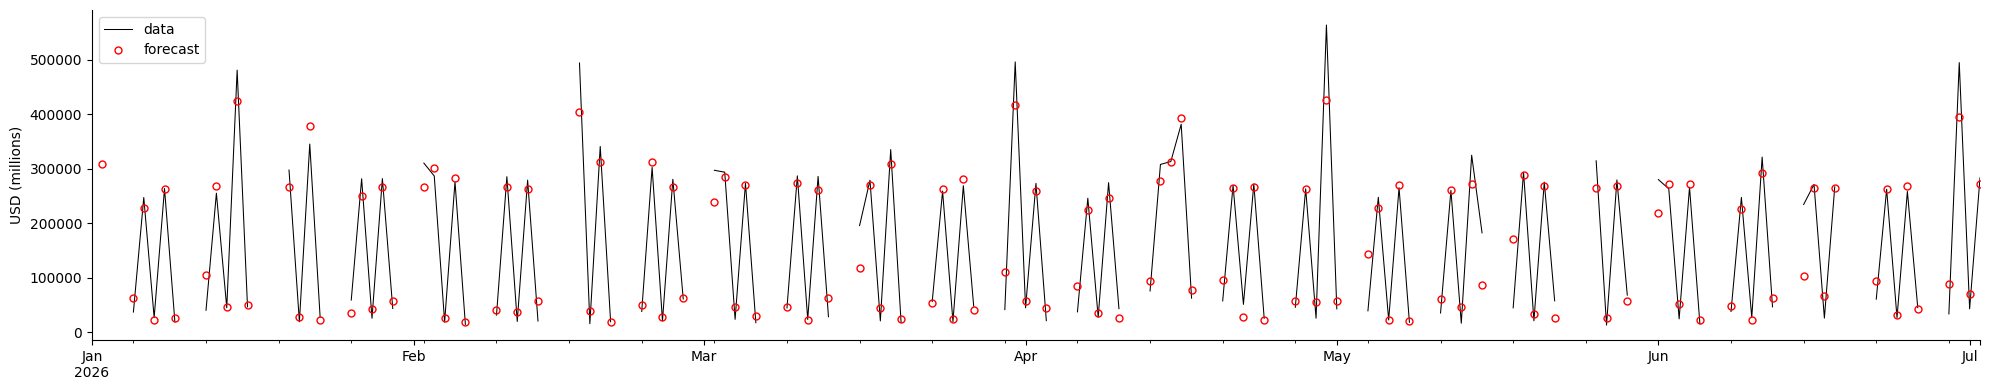

In [14]:
# prepare data for plot
year_df = series.to_dataframe()
year_df = year_df[year_df.index.year == 2026] # isolate 2025
year_ts = TimeSeries.from_dataframe(year_df)
obs = ~np.isnan(year_ts.values()).flatten() # plot only days with observations
xx = df_forecast.index[obs]
yy = df_forecast.FLOW.values[obs]

# plot a chart
plt.figure(figsize=(20,4))
year_ts.plot(color='k', linewidth=.75, label='data')
plt.plot(xx, yy, 'or', markersize=5, mfc='none', label='forecast')
plt.ylabel('USD (millions)', fontweight='normal')
plt.xlabel(None)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.legend()
plt.tight_layout()
plt.show()
